![imagen](https://cdn.foodbeast.com/content/wp-content/uploads/2012/03/beer-print-01-selectism.jpg)

# Ejercicio pandas estadística
Para este ejercicio se ha utilizado [un dataset de un concurso de kaggle](https://www.kaggle.com/nickhould/craft-cans), cuyo reto consiste en predecir el tipo de cerveza en función de sus características (nivel de alcohol, amargura, tamaño...).

# Ejercicio 1
Importa las librerias que consideres

In [49]:
import pandas as pd
import numpy as np

In [50]:
# la función que hace que salgan los df bonitos, unos al lado de otros:

class display(object):
    """Representador HTML de múltiples objetos"""
    template = """<div style="float: left; padding: 10px;">
    <p style='font-family:"Courier New", Courier, monospace'>{0}</p>{1}
    </div>"""
    def __init__(self, *args):
        self.args = args
        
    def _repr_html_(self):
        return '\n'.join(self.template.format(a, eval(a)._repr_html_())
                         for a in self.args)
    
    def __repr__(self):
        return '\n\n'.join(a + '\n' + repr(eval(a))
                           for a in self.args)
    

## Ejercicio 2
1. Importa el dataset "datasets_beer.csv"
2. Imprime por pantalla los primeros registros.
3. ¿Cuáles son sus columnas?
4. ¿Qué dimensiones tiene el DataFrame?

In [51]:
# 1:
data_birras = pd.read_csv('data/datasets_beers.csv')


In [52]:
# 2:
data_birras.head()

,Unnamed: 0,abv,ibu,id,name,style,brewery_id,ounces
0,0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0
1,1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0
2,2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0
3,3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0
4,4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0


In [53]:
# 3:
print('Columnas:', data_birras.columns.tolist())

# 4:
print('Dimensiones:', data_birras.shape)

Columnas: ['Unnamed: 0', 'abv', 'ibu', 'id', 'name', 'style', 'brewery_id', 'ounces']
Dimensiones: (2410, 8)


In [54]:
'''
pa entenderme al hacer los ejercicios y saber a qué columna llamar:

abv: The alcoholic content by volume with 0 being no alcohol and 1 being pure alcohol.
ibu: International bittering units, which describe how bitter a drink is.
style: Beer style (lager, ale, IPA, etc.)
brewery: Unique identifier for brewery that produces this beer; can use to join with brewery info.
ounces: Size of beer in ounces.
name: Name of the beer.
'''

'\npa entenderme al hacer los ejercicios y saber a qué columna llamar:\n\nabv: The alcoholic content by volume with 0 being no alcohol and 1 being pure alcohol.\nibu: International bittering units, which describe how bitter a drink is.\nstyle: Beer style (lager, ale, IPA, etc.)\nbrewery: Unique identifier for brewery that produces this beer; can use to join with brewery info.\nounces: Size of beer in ounces.\nname: Name of the beer.\n'

## Ejercicio 3
[Elimina la columna "Unnamed: 0"](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html)

In [55]:
data_birras = data_birras.drop(columns = ['Unnamed: 0'])

data_birras


,abv,ibu,id,name,style,brewery_id,ounces
0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0
1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0
2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0
3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0
4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0
...,...,...,...,...,...,...,...
2405,0.067,45.0,928,Belgorado,Belgian IPA,424,12.0
2406,0.052,NaN,807,Rail Yard Ale,American Amber / Red Ale,424,12.0
2407,0.055,NaN,620,B3K Black Lager,Schwarzbier,424,12.0
2408,0.055,40.0,145,Silverback Pale Ale,American Pale Ale (APA),424,12.0


## Ejercicio 4
¿Cuántas filas y columnas tiene el dataset?

In [61]:
# filas:
data_birras.shape[0]

2410

In [62]:
# columnas: 
data_birras.shape[1]

7

In [63]:
# total filas y columnas:
data_birras.shape

(2410, 7)

In [ ]:
# pensé que igual estaba bien ponerlo cuqui:

print(f'Num de filas: {data_birras.shape[0]}, Num de columnas: {data_birras.shape[1]}')
print(f'Total: {data_birras.shape}')

Num de filas: 2410, Num de columnas: 7
Total: (2410, 7)


## Ejercicio 5
¿De qué tipo son los datos?

In [57]:
data_birras.dtypes

abv           float64
ibu           float64
id              int64
name              str
style             str
brewery_id      int64
ounces        float64
dtype: object

In [58]:
data_birras.info()

<class 'pandas.DataFrame'>
RangeIndex: 2410 entries, 0 to 2409
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   abv         2348 non-null   float64
 1   ibu         1405 non-null   float64
 2   id          2410 non-null   int64  
 3   name        2410 non-null   str    
 4   style       2405 non-null   str    
 5   brewery_id  2410 non-null   int64  
 6   ounces      2410 non-null   float64
dtypes: float64(3), int64(2), str(2)
memory usage: 131.9 KB


## Ejercicio 6
Obtén en un nuevo DataFrame un resumen con las principales estadísticas de las columnas numéricas: mean, max, count, cuartiles...

In [59]:
data_birras.describe()

,abv,ibu,id,brewery_id,ounces
count,2348.000000,1405.000000,2410.000000,2410.000000,2410.000000
mean,0.059773,42.713167,1431.113278,231.749793,13.592241
std,0.013542,25.954066,752.459975,157.685604,2.352204
min,0.001000,4.000000,1.000000,0.000000,8.400000
25%,0.050000,21.000000,808.250000,93.000000,12.000000
50%,0.056000,35.000000,1453.500000,205.000000,12.000000
75%,0.067000,64.000000,2075.750000,366.000000,16.000000
max,0.128000,138.000000,2692.000000,557.000000,32.000000


## Ejercicio 7
¿Cuántas birras hay de cada estilo en este dataset? [Investiga en la documentación de Series](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.html) si puedes hacer un conteo de valores.

In [28]:
data_birras['style'].value_counts()

style
American IPA                      424
American Pale Ale (APA)           245
American Amber / Red Ale          133
American Blonde Ale               108
American Double / Imperial IPA    105
                                 ... 
American Malt Liquor                1
Grisette                            1
Flanders Oud Bruin                  1
Braggot                             1
Low Alcohol Beer                    1
Name: count, Length: 99, dtype: int64

## Ejercicio 8
1. Imprime por pantalla los registros desde el décimo hasta el vigésimo
2. De esos registros, imprime por pantalla desde la columna `name` a `ounces`, ambas incluidas
3. Quédate con las columnas `abv`, `ibu` y `ounces`, y además quédate sólo con los registros 10 al 20.
4. Convierte el resultado del apartado 3 en un array de `numpy`

In [33]:
# 1:
reg_10_20 = data_birras.iloc[10:21]

reg_10_20

,abv,ibu,id,name,style,brewery_id,ounces
10,0.072,NaN,2099,Sophomoric Saison,Saison / Farmhouse Ale,177,12.0
11,0.073,NaN,2098,Regional Ring Of Fire,Saison / Farmhouse Ale,177,12.0
12,0.069,NaN,2097,Garce Selé,Saison / Farmhouse Ale,177,12.0
13,0.085,NaN,1980,Troll Destroyer,Belgian IPA,177,12.0
14,0.061,60.0,1979,Bitter Bitch,American Pale Ale (APA),177,12.0
15,0.060,NaN,2318,Ginja Ninja,Cider,154,12.0
16,0.060,NaN,2170,Cherried Away,Cider,154,12.0
17,0.060,NaN,2169,Rhubarbarian,Cider,154,12.0
18,0.060,NaN,1502,BrightCider,Cider,154,12.0
19,0.082,NaN,1593,He Said Baltic-Style Porter,Baltic Porter,368,12.0


In [35]:
# 2:
cols_name_ounces = data_birras.loc[10:20, 'name':'ounces']

cols_name_ounces


,name,style,brewery_id,ounces
10,Sophomoric Saison,Saison / Farmhouse Ale,177,12.0
11,Regional Ring Of Fire,Saison / Farmhouse Ale,177,12.0
12,Garce Selé,Saison / Farmhouse Ale,177,12.0
13,Troll Destroyer,Belgian IPA,177,12.0
14,Bitter Bitch,American Pale Ale (APA),177,12.0
15,Ginja Ninja,Cider,154,12.0
16,Cherried Away,Cider,154,12.0
17,Rhubarbarian,Cider,154,12.0
18,BrightCider,Cider,154,12.0
19,He Said Baltic-Style Porter,Baltic Porter,368,12.0


In [ ]:
# 3:
muchas_cosas = data_birras.loc[10:20, ['abv', 'ibu', 'ounces']]

muchas_cosas


,abv,ibu,ounces
10,0.072,NaN,12.0
11,0.073,NaN,12.0
12,0.069,NaN,12.0
13,0.085,NaN,12.0
14,0.061,60.0,12.0
15,0.060,NaN,12.0
16,0.060,NaN,12.0
17,0.060,NaN,12.0
18,0.060,NaN,12.0
19,0.082,NaN,12.0


In [42]:
# 4:
array_muchas_cosas = muchas_cosas.to_numpy()
print(array_muchas_cosas)
print()
print(type(array_muchas_cosas))

[[ 0.072    nan 12.   ]
 [ 0.073    nan 12.   ]
 [ 0.069    nan 12.   ]
 [ 0.085    nan 12.   ]
 [ 0.061 60.    12.   ]
 [ 0.06     nan 12.   ]
 [ 0.06     nan 12.   ]
 [ 0.06     nan 12.   ]
 [ 0.06     nan 12.   ]
 [ 0.082    nan 12.   ]
 [ 0.082    nan 12.   ]]

<class 'numpy.ndarray'>


## Ejercicio 9
¿Cuántas onzas pesan todas las birras del dataset?

In [65]:
data_birras["ounces"].sum()

# printeado cuqui:
print(f'Todas las birras del dataset pesan {data_birras["ounces"].sum()} onzas.') 

Todas las birras del dataset pesan 32757.3 onzas.


## Ejercicio 10
El amargor de las cervezas se mide por su nivel de IBUs.
1. ¿Cuál es el amargor medio de las cervezas?
2. ¿El máximo? ¿Y el mínimo?
3. ¿Qué cerveza es la que tiene el amargor máximo? ¿Cuál es la de amargor mínimo?

In [66]:
# 1:
data_birras["ibu"].mean()
# cuqui:
print(f'El amargor medio de las birras es de {data_birras["ibu"].mean()}.') 

El amargor medio de las birras es de 42.71316725978647.


In [67]:
# 2:
data_birras["ibu"].max()

# cuqui:
print(f'El amargor máximo de las birras es de {data_birras["ibu"].max()}.') 

El amargor máximo de las birras es de 138.0.


In [68]:
#2:
data_birras["ibu"].min()
# cuqui:
print(f'El amargor mínimo de las birras es de {data_birras["ibu"].min()}.') 

El amargor mínimo de las birras es de 4.0.


In [72]:
# 3:
max_ibu_birra = data_birras.loc[data_birras['ibu'].idxmax()]
min_ibu_birra = data_birras.loc[data_birras['ibu'].idxmin()]

# cuqui:
print(f"El tipo de cerveza con el máximo amargor es {max_ibu_birra['name']}, con un amargor de {max_ibu_birra['ibu']} IBUs.")
print(f"El tipo de cerveza con el amargor mínimo es {min_ibu_birra['name']}, con un amargor de {min_ibu_birra['ibu']} IBUs.")

El tipo de cerveza con el máximo amargor es Bitter Bitch Imperial IPA, con un amargor de 138.0 IBUs.
El tipo de cerveza con el amargor mínimo es Summer Solstice, con un amargor de 4.0 IBUs.


## Ejercicio 11
No queda muy claro cuánto de dispar, de dispersa, es la medida de IBU. Mediante estadística descriptiva (una o dos métricas, sin gráficas), razona la dispersión de la variable IBU.

In [76]:
# para mirar la dispersión de los datos del amargor (IBU) tengo que mirar la desviación estándar
# y el coeficiente de variación
desv_estandar_ibu = data_birras['ibu'].std()
mean_ibu = data_birras['ibu'].mean()
coef_var_ibu = (desv_estandar_ibu / mean_ibu) * 100

print(f'Desviación estándar del amargor: {desv_estandar_ibu:.2f}.') # añado el .2f porque al ejecutar código me salían 800mil decimales y con 2 voy que chutp
print(f'Coeficiente de variación del amargor: {coef_var_ibu:.2f}%.')
print('\nSe ve una alta desvición típica que, junto con el coeficiente de variación, indican que la variable "ibu" está muy dispersa.')
print('Se podría traducir en que hay una gran variabilidad en el amargor de las birras.')


Desviación estándar del amargor: 25.95.
Coeficiente de variación del amargor: 60.76%.

Se ve una alta desvición típica que, junto con el coeficiente de variación, indican que la variable "ibu" está muy dispersa.
Se podría traducir en que hay una gran variabilidad en el amargor de las birras.


In [78]:
# buscando en internet, al parecer tengo que añadir también el rango intercuartílico (IQR)
# para eso tengo que ver cuáles son los cuartiles 1 y 3
cuartil_1 = data_birras['ibu'].quantile(0.25) 
cuartil_3 = data_birras['ibu'].quantile(0.75)
rango_intercuartilico = cuartil_3 - cuartil_1
print(f'\nRango intercuartílico (IQR): {rango_intercuartilico}')
print(f'Q1: {cuartil_1}, Q3: {cuartil_3}')


Rango intercuartílico (IQR): 43.0
Q1: 21.0, Q3: 64.0


## Ejercicio 12
¿Existe alguna relación lineal entre las variables numéricas del dataset? Intenta pintar este razonamiento mediante un gráfico

In [ ]:
# %pip install numpy pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
# voy a guiarme por el documento '3.Ejemplo de análisis exploratorio' que dimos el primer día

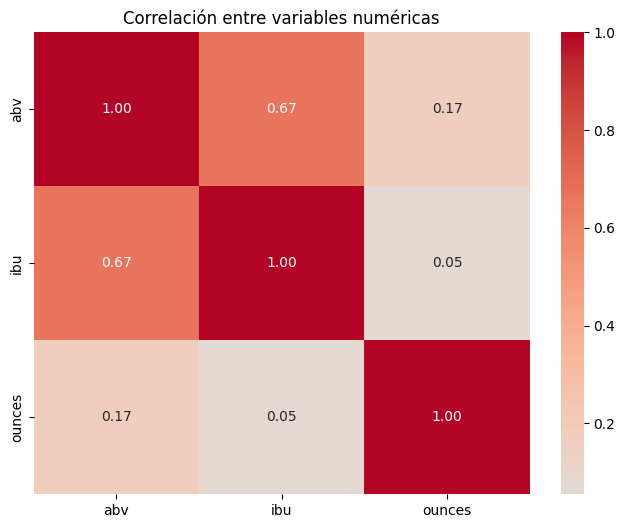

" no hace falta porque no se ve la relación entre las 3 variables numéricas, sólo entre 2:\n\n# también si creo un diagrama de dispersión de 'abv' e 'ibu' se ve bien la relación entre 'abv' e 'ibu', que puede ser interesante\nplt.figure(figsize=(8, 6))\nsns.scatterplot(data=data_birras, x='abv', y='ibu', alpha=0.5)\nplt.title('Relación entre ABV e IBU')\nplt.xlabel('ABV')\nplt.ylabel('IBU')\nplt.show()\n"

In [100]:
# por lo que veo hay que hacer una matriz de correlacion antes de hacer el siguiente paso
matrix_correlacion = data_birras[['abv', 'ibu', 'ounces']].corr() # pongo aquí todas las variables numéricas

# creo un mapa de calor, que se ve muy bien la relación de las distintas variables
plt.figure(figsize=(8, 6))
sns.heatmap(matrix_correlacion, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlación entre variables numéricas')
plt.show()

''' no hace falta porque no se ve la relación entre las 3 variables numéricas, sólo entre 2:

# también si creo un diagrama de dispersión de 'abv' e 'ibu' se ve bien la relación entre 'abv' e 'ibu', que puede ser interesante
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data_birras, x='abv', y='ibu', alpha=0.5)
plt.title('Relación entre ABV e IBU')
plt.xlabel('ABV')
plt.ylabel('IBU')
plt.show()
'''

## Ejercicio 13
Representa el nivel de alcohol (columna `abv`) en un histograma. ¿Se trata de una distribución simétrica o asimétrica?

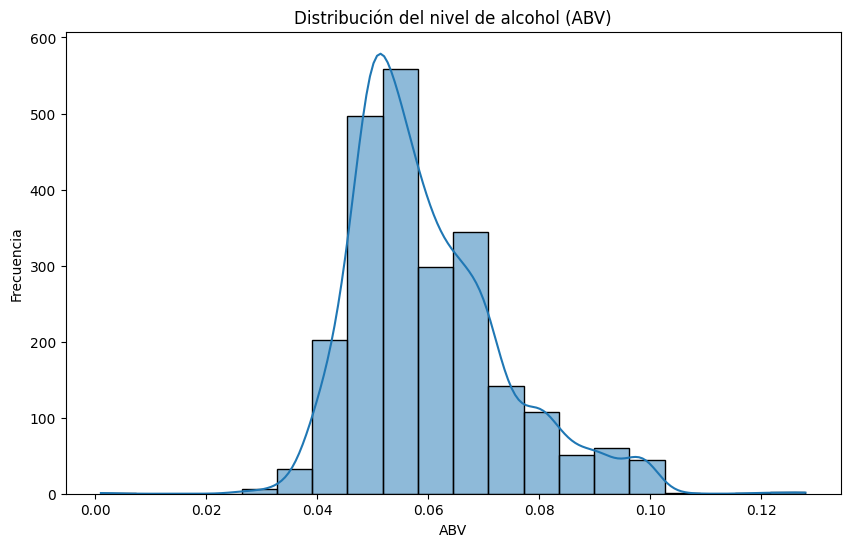

El coeficiente de asimetría es de 0.958.
La distribución tiene una asimatría positiva (colita hacia la derecha).


In [87]:
# hisgograma:
plt.figure(figsize=(10, 6))
sns.histplot(data=data_birras, x='abv', bins=20, kde=True)
plt.title('Distribución del nivel de alcohol (ABV)')
plt.xlabel('ABV')
plt.ylabel('Frecuencia')
plt.show()

# ahora calculo la asimetría:
coef_asime = data_birras['abv'].skew()
print(f'El coeficiente de asimetría es de {coef_asime:.3f}.') # pongo 3 decimales porque es lo habitual

if coef_asime > 0:
    print('La distribución tiene una asimatría positiva (colita hacia la derecha).')
elif coef_asime < 0:
    print('La distribución tiene una asimatría negativa (colita hacia la izquierda).')
else:
    print('La distribución es simétrica.')

## Ejercicio 14
Representa mediante un *boxplot* de `seaborn` la variable `abv`

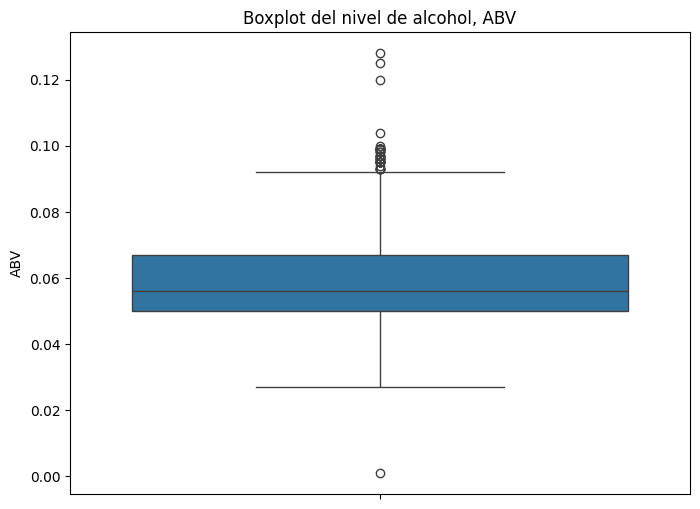

In [88]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=data_birras, y='abv')
plt.title('Boxplot del nivel de alcohol, ABV')
plt.ylabel('ABV')
plt.show()

## Ejercicio 15
1. ¿Qué estilos son los que tienen en media más alcohol?
2. ¿Y los estilos que son en media más amargos?

In [ ]:
# 1. media más alcohol por tipo:
abv_por_tipo = data_birras.groupby('style')['abv'].mean().sort_values(ascending=False)
abv_por_tipo.head(10) # muestro los 10 primerps


style
English Barleywine                  0.107667
Quadrupel (Quad)                    0.104000
American Barleywine                 0.099000
American Malt Liquor                0.099000
Russian Imperial Stout              0.097636
American Double / Imperial Stout    0.093667
American Double / Imperial IPA      0.087369
Tripel                              0.086818
Baltic Porter                       0.085167
Belgian Strong Pale Ale             0.084000
Name: abv, dtype: float64

In [93]:
# 2. media más amargor por tipo:
ibu_por_tipo = data_birras.groupby('style')['ibu'].mean().sort_values(ascending=False)
ibu_por_tipo.head(10)

style
American Barleywine                   96.000000
American Double / Imperial IPA        93.320000
Russian Imperial Stout                86.500000
American Double / Imperial Pilsner    85.000000
Belgian Strong Dark Ale               72.000000
American Black Ale                    68.900000
American IPA                          67.634551
English Barleywine                    66.666667
English Stout                         66.000000
American Strong Ale                   65.416667
Name: ibu, dtype: float64

## Ejercicio 16
Carga el datasets de cervecerias `datasets_breweries.csv`

In [94]:
breweries = pd.read_csv('data/datasets_breweries.csv')
breweries

,Unnamed: 0,name,city,state
0,0,NorthGate Brewing,Minneapolis,MN
1,1,Against the Grain Brewery,Louisville,KY
2,2,Jack's Abby Craft Lagers,Framingham,MA
3,3,Mike Hess Brewing Company,San Diego,CA
4,4,Fort Point Beer Company,San Francisco,CA
...,...,...,...,...
553,553,Covington Brewhouse,Covington,LA
554,554,Dave's Brewfarm,Wilson,WI
555,555,Ukiah Brewing Company,Ukiah,CA
556,556,Butternuts Beer and Ale,Garrattsville,NY


## Ejercicio 17
1. Renombra la columna `Unnamed: 0` como `brewery_id`
2. Renombra también la columna `name` por `brewery_name`. ¿Puedes hacer ambos apartados en una sola sentencia?

In [97]:
# voy intentar hacerlo en una sóla línea de código:
breweries = breweries.rename(columns={'Unnamed: 0': 'brewery_id', 'name': 'brewery_name'})
breweries

,brewery_id,brewery_name,city,state
0,0,NorthGate Brewing,Minneapolis,MN
1,1,Against the Grain Brewery,Louisville,KY
2,2,Jack's Abby Craft Lagers,Framingham,MA
3,3,Mike Hess Brewing Company,San Diego,CA
4,4,Fort Point Beer Company,San Francisco,CA
...,...,...,...,...
553,553,Covington Brewhouse,Covington,LA
554,554,Dave's Brewfarm,Wilson,WI
555,555,Ukiah Brewing Company,Ukiah,CA
556,556,Butternuts Beer and Ale,Garrattsville,NY


## Ejercicio 18
Junta los dos datasets que tienes

In [113]:
df_merge = data_birras.merge(breweries, on='brewery_id', how='left')
df_merge

,abv,ibu,id,name,style,brewery_id,ounces,brewery_name,city,state
0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0,10 Barrel Brewing Company,Bend,OR
1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0,18th Street Brewery,Gary,IN
2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0,18th Street Brewery,Gary,IN
3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0,18th Street Brewery,Gary,IN
4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0,18th Street Brewery,Gary,IN
...,...,...,...,...,...,...,...,...,...,...
2405,0.067,45.0,928,Belgorado,Belgian IPA,424,12.0,Wynkoop Brewing Company,Denver,CO
2406,0.052,NaN,807,Rail Yard Ale,American Amber / Red Ale,424,12.0,Wynkoop Brewing Company,Denver,CO
2407,0.055,NaN,620,B3K Black Lager,Schwarzbier,424,12.0,Wynkoop Brewing Company,Denver,CO
2408,0.055,40.0,145,Silverback Pale Ale,American Pale Ale (APA),424,12.0,Wynkoop Brewing Company,Denver,CO


## Ejercicio 19
1. ¿Cuántos estados diferentes hay?
2. ¿Y ciudades diferentes?
3. ¿Cuántas cervecerías hay?

In [107]:
# 1, estados diferentes:
df_merge["state"].nunique()


51

In [108]:
# 2, ciudades diferentes:
df_merge["city"].nunique()


384

In [109]:
# 3, cervecerías:
df_merge["brewery_id"].nunique()

558

## Ejercicio 20
Agrupa por estado y ciudad, la media, mediana y máximo nivel de alcohol

In [114]:
abv_estado = df_merge.groupby(['state', 'city'])['abv'].agg(['mean', 'median', 'max'])
abv_estado.columns = ['abv_mean', 'abv_median', 'abv_max']

abv_estado

abv_mean  abv_median  abv_max
state city                                     
AK    Anchorage   0.054200      0.0520    0.063
      Juneau      0.053000      0.0530    0.053
      Soldotna    0.058500      0.0580    0.068
      Talkeetna   0.059500      0.0585    0.065
AL    Birmingham  0.065400      0.0600    0.093
...                    ...         ...      ...
WI    Wilson      0.055000      0.0550    0.055
WV    Lewisburg   0.062000      0.0620    0.067
WY    Jackson     0.054857      0.0520    0.068
      Pinedale    0.061000      0.0610    0.072
      Sheridan    0.052833      0.0480    0.070

[401 rows x 3 columns]

## Ejercicio 21
¿Cuáles son las cervezas más amargas que se consumen en Indiana, estado = `IN`?

In [ ]:
# filtro por estado IN y ordeno por IBU descendiente
in_beers = df_merge[df_merge['state'] == 'IN'][['name', 'ibu', 'style', 'brewery_name']]
most_bitter_in = in_beers.sort_values('ibu', ascending=False)

most_bitter_in

## Ejercicio 22
Obtén una tabla con los principales estadísticos del campo `ibu`,  a nivel ciudad

In [ ]:
ibu_by_city = df_merge.groupby('city')['ibu'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])
ibu_by_city.columns = ['ibu_mean', 'ibu_median', 'ibu_std', 'ibu_min', 'ibu_max', 'ibu_count']
display(ibu_by_city.head(20))

## Ejercicio 23
Consigue en un DataFrame de todas las cervezas en cuyas cervecerías al menos haya una cerveza con un `abv` mínimo 0.07.

In [ ]:
# Encontrar cervecerías con al menos una cerveza con abv >= 0.07
breweries_high_abv = df_merge.groupby('brewery_id')['abv'].max()
breweries_with_high_abv = breweries_high_abv[breweries_high_abv >= 0.07].index

# Filtrar el dataframe para obtener todas las cervezas de esas cervecerías
df_high_abv_breweries = df_merge[df_merge['brewery_id'].isin(breweries_with_high_abv)]
print(f'Número de cervezas en cervecerías con abv >= 0.07: {len(df_high_abv_breweries)}')
df_high_abv_breweries[['name', 'abv', 'brewery_name']]

## Ejercicio 24
Teniendo en cuenta la media de amargor de todas las cervezas, obtén una tabla con las cervezas cuyos estados tengan una media de amargor en cerveza por encima de la media

In [ ]:
# Calcular la media global de IBU
global_ibu_mean = df_merge['ibu'].mean()
print(f'Media global de IBU: {global_ibu_mean:.2f}')

# Calcular la media de IBU por estado
ibu_by_state = df_merge.groupby('state')['ibu'].mean()

# Encontrar estados con media de IBU por encima de la media global
states_above_avg = ibu_by_state[ibu_by_state > global_ibu_mean].index
print(f'\nEstados con IBU medio por encima de la media: {list(states_above_avg)}')

# Filtrar las cervezas de esos estados
beers_above_avg_states = df_merge[df_merge['state'].isin(states_above_avg)][['name', 'ibu', 'state', 'style']]
print(f'\nNúmero de cervezas en esos estados: {len(beers_above_avg_states)}')
beers_above_avg_states